# Post Pandemic Regime Shifts in Labor Market: Structural Benchmark

## Purpose


## Research Context


## Imports and Configuration

In [1]:
%matplotlib inline

from IPython.display import display

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from pathlib import Path

from scipy.stats import norm
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from regime_shift.config import (
    FIG_ROOT as fig_root,
    MODEL_ROOT as model_root,
    PRICE_MODEL_READY_PATH as price_model_ready_path,
    REPORT_ROOT as report_root,
    SAVE_DPI as save_dpi,
    SHOW_DEC as show_dec,
    WAGE_MODEL_READY_PATH as wage_model_ready_path,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for path in (fig_root, model_root, report_root):
    Path(path).mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

## Load Dataset

In [2]:
wage_data = pd.read_csv(wage_model_ready_path)
price_data = pd.read_csv(price_model_ready_path)

for data in [wage_data, price_data]:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data.dropna(subset=["date"], inplace=True)
    data.sort_values("date", inplace=True)
    data.reset_index(drop=True, inplace=True)

display(wage_data.head())
display(price_data.head())

,date,regime,split_role,pre_regime,shock_regime,post_regime,wage_3_valid,wage_3_train,wage_3_shock,wage_3_post,cpi_3_valid,cpi_3_train,cpi_3_shock,cpi_3_post,pce_3_valid,pce_3_train,pce_3_shock,pce_3_post,wage_6_valid,wage_6_train,wage_6_shock,wage_6_post,cpi_6_valid,cpi_6_train,cpi_6_shock,cpi_6_post,pce_6_valid,pce_6_train,pce_6_shock,pce_6_post,wage_12_valid,wage_12_train,wage_12_shock,wage_12_post,cpi_12_valid,cpi_12_train,cpi_12_shock,cpi_12_post,pce_12_valid,pce_12_train,pce_12_shock,pce_12_post,consumer_sentiment,consumer_sentiment_chg_1,consumer_sentiment_chg_3,consumer_sentiment_lag_1,consumer_sentiment_lag_3,credit_stress,fed_funds,fed_funds_chg_1,fed_funds_chg_3,fed_funds_lag_1,fed_funds_lag_3,high_inflation,hy_oas,hy_oas_chg_1,hy_oas_chg_3,hy_oas_lag_1,hy_oas_lag_3,jolts_ratio,jolts_ratio_lag_1,jolts_ratio_lag_3,jolts_ratio_lag_6,log_jolts_ratio,log_jolts_ratio_chg_1,log_jolts_ratio_chg_3,log_jolts_ratio_chg_6,log_jolts_ratio_lag_1,log_jolts_ratio_lag_3,log_jolts_ratio_lag_6,log_jolts_ratio_std_12,log_jolts_ratio_std_3,log_jolts_ratio_std_6,quits_rate,quits_rate_chg_1,quits_rate_chg_3,quits_rate_chg_6,quits_rate_lag_1,quits_rate_lag_3,quits_rate_lag_6,tight_labor,unemployment_rate,unemployment_rate_chg_1,unemployment_rate_chg_3,unemployment_rate_chg_6,unemployment_rate_lag_1,unemployment_rate_lag_3,unemployment_rate_lag_6,wage_target_3,design_name,target_name,target_valid,wage_target_6,wage_target_12
0,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wage_3_full,wage_target_3,0,NaN,NaN
1,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wage_6_full,wage_target_6,0,NaN,NaN
2,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wage_12_full,wage_target_12,0,NaN,NaN
3,2000-02-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,111.3000,-0.7000,NaN,112.0000,NaN,0,5.7300,0.2800,NaN,5.4500,NaN,0,4.9024,0.1181,NaN,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.1000,0.1000,NaN,NaN,4.0000,NaN,NaN,NaN,wage_3_full,wage_target_3,0,NaN,NaN
4,2000-02-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,111.3000,-0.7000,NaN,112.0000,NaN,0,5.7300,0.2800,NaN,5.4500,NaN,0,4.9024,0.1181,NaN,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.1000,0.1000,NaN,NaN,4.0000,NaN,NaN,NaN,wage_6_full,wage_target_6,0,NaN,NaN


,date,regime,split_role,pre_regime,shock_regime,post_regime,wage_3_valid,wage_3_train,wage_3_shock,wage_3_post,cpi_3_valid,cpi_3_train,cpi_3_shock,cpi_3_post,pce_3_valid,pce_3_train,pce_3_shock,pce_3_post,wage_6_valid,wage_6_train,wage_6_shock,wage_6_post,cpi_6_valid,cpi_6_train,cpi_6_shock,cpi_6_post,pce_6_valid,pce_6_train,pce_6_shock,pce_6_post,wage_12_valid,wage_12_train,wage_12_shock,wage_12_post,cpi_12_valid,cpi_12_train,cpi_12_shock,cpi_12_post,pce_12_valid,pce_12_train,pce_12_shock,pce_12_post,consumer_sentiment,consumer_sentiment_chg_1,consumer_sentiment_chg_3,consumer_sentiment_lag_1,consumer_sentiment_lag_3,credit_stress,fed_funds,fed_funds_chg_1,fed_funds_chg_3,fed_funds_lag_1,fed_funds_lag_3,high_inflation,hy_oas,hy_oas_chg_1,hy_oas_chg_3,hy_oas_lag_1,hy_oas_lag_3,jolts_ratio,jolts_ratio_lag_1,jolts_ratio_lag_3,jolts_ratio_lag_6,log_jolts_ratio,log_jolts_ratio_chg_1,log_jolts_ratio_chg_3,log_jolts_ratio_chg_6,log_jolts_ratio_lag_1,log_jolts_ratio_lag_3,log_jolts_ratio_lag_6,log_jolts_ratio_std_12,log_jolts_ratio_std_3,log_jolts_ratio_std_6,quits_rate,quits_rate_chg_1,quits_rate_chg_3,quits_rate_chg_6,quits_rate_lag_1,quits_rate_lag_3,quits_rate_lag_6,tight_labor,unemployment_rate,unemployment_rate_chg_1,unemployment_rate_chg_3,unemployment_rate_chg_6,unemployment_rate_lag_1,unemployment_rate_lag_3,unemployment_rate_lag_6,cpi_target_3,design_name,target_name,target_valid,pce_target_3,cpi_target_6,pce_target_6,cpi_target_12,pce_target_12
0,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,3.7625,cpi_3_full,cpi_target_3,1,NaN,NaN,NaN,NaN,NaN
1,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pce_3_full,pce_target_3,1,2.6393,NaN,NaN,NaN,NaN
2,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cpi_6_full,cpi_target_6,1,NaN,3.9767,NaN,NaN,NaN
3,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pce_6_full,pce_target_6,1,NaN,NaN,2.6631,NaN,NaN
4,2000-01-01,Pre-2020,pre_train,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,0,112.0000,NaN,NaN,NaN,NaN,0,5.4500,NaN,NaN,NaN,NaN,0,4.7843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pce_12_full,pce_target_12,1,NaN,NaN,NaN,NaN,2.6656


## Targets and Modes

In [3]:
def target_map() -> dict:
    return {
        "wage": [
            "wage_target_3",
            "wage_target_6",
            "wage_target_12",
        ],
        "price": [
            "cpi_target_3",
            "cpi_target_6",
            "cpi_target_12",
            "pce_target_3",
            "pce_target_6",
            "pce_target_12",
        ],
    }

In [4]:
all_targets = target_map()["wage"] + target_map()["price"]
structural_signal = "log_jolts_ratio"
structural_controls = ["fed_funds", "hy_oas"]

In [5]:
forecast_models = [
    "Persistence",
    "AR",
    "OLS",
    "Ridge",
    "ElasticNet",
    "Huber",
    "RandomForest",
    "GradientBoosting",
]

In [6]:
mode_list = ["AR", "Base", "Quits", "Jobless", "Mix", "Curve"]
signal_models = ["OLS", "Ridge", "ElasticNet", "Huber"]

## Helper Functions

In [7]:
def horizon(target_col: str) -> int:
    return int(target_col.rsplit("_", 1)[-1])

In [8]:
def target_name(target_col):
    if target_col.startswith("wage_"):
        return "Wage"
    if target_col.startswith("cpi_"):
        return "CPI"
    if target_col.startswith("pce_"):
        return "PCE"
    raise ValueError("Target column isn't supported.")

In [9]:
def unique_cols(cols: list[str]) -> list[str]:
    seen = set()
    out = []

    for col in cols:
        if col not in seen:
            seen.add(col)
            out.append(col)

    return out

In [10]:
def add_target_lag(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, str]:
    lag_col = f"{target_col}_lag"
    out = data.copy()
    out[lag_col] = out[target_col].shift(horizon(target_col))

    return out, lag_col

In [11]:
def base_feature_block(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str], str]:
    out, lag_col = add_target_lag(data, target_col)

    feat_cols = unique_cols(
        [
            structural_signal,
            lag_col,
            *structural_controls,
        ]
    )

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, [col for col in keep_cols if col in out.columns]].copy()
    out = out.dropna().reset_index(drop=True)

    return out, feat_cols, lag_col

In [12]:
def fetch_base_data(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str], str]:
    return base_feature_block(data, target_col)

In [13]:
def fetch_data(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample, feat_cols, lag_col = fetch_base_data(data, target_col)

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            lag_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    return sample.loc[:, keep_cols].copy()

In [14]:
def sample_summary(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample = fetch_data(data, target_col)

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "rows": [len(sample)],
            "start": [sample["date"].min()],
            "end": [sample["date"].max()],
            "pre_rows": [int(sample["pre_regime"].sum())],
            "shock_rows": [int(sample["shock_regime"].sum())],
            "post_rows": [int(sample["post_regime"].sum())],
        }
    )

In [15]:
sample_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    sample_parts.append(sample_summary(base_data, target_col))

sample_data = pd.concat(sample_parts, ignore_index=True)
display(sample_data.sort_values(["target", "horizon"]).reset_index(drop=True))

,target,target_col,horizon,rows,start,end,pre_rows,shock_rows,post_rows
0,CPI,cpi_target_3,3,31,2001-05-01,2025-01-01,26,1,4
1,CPI,cpi_target_6,6,48,2001-04-01,2025-08-01,33,3,12
2,CPI,cpi_target_12,12,42,2001-07-01,2024-08-01,35,2,5
3,PCE,pce_target_3,3,31,2001-02-01,2025-06-01,26,3,2
4,PCE,pce_target_6,6,53,2001-06-01,2025-07-01,39,3,11
5,PCE,pce_target_12,12,47,2001-08-01,2024-07-01,37,3,7
6,Wage,wage_target_3,3,109,2006-06-01,2025-09-01,87,6,16
7,Wage,wage_target_6,6,94,2006-07-01,2025-09-01,67,9,18
8,Wage,wage_target_12,12,37,2007-10-01,2024-10-01,22,6,9


## Evaluation Metrics

In [16]:
def root_mean_square_error(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(actual, pred)))


def mean_absolute_error_value(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(mean_absolute_error(actual, pred))


def out_sample_r_squared(actual: np.ndarray, pred: np.ndarray, base_pred: np.ndarray) -> float:
    model_mse = mean_squared_error(actual, pred)
    base_mse = mean_squared_error(actual, base_pred)

    if base_mse == 0:
        return np.nan

    return float(1.0 - (model_mse / base_mse))


def score_row(
    target_col: str,
    model: str,
    split: str,
    actual: np.ndarray,
    pred: np.ndarray,
    base_pred: np.ndarray,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
) -> dict:
    return {
        "target": target_name(target_col),
        "target_col": target_col,
        "horizon": horizon(target_col),
        "model": model,
        "split": split,
        "rmse": root_mean_square_error(actual, pred),
        "mae": mean_absolute_error_value(actual, pred),
        "oos_r2_vs_persistence": out_sample_r_squared(actual, pred, base_pred),
        "row_count": len(actual),
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
    }

##  Modeling  Set-Up

In [17]:
def fit_persistence(train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    last_value = float(train_target.iloc[-1])
    return np.repeat(last_value, len(test_feat))


def fit_ols(train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    train_data = sm.add_constant(train_feat, has_constant="add")
    test_data = sm.add_constant(test_feat, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_target, train_data).fit()
    pred = fit.predict(test_data)

    return np.asarray(pred)


def fit_pipe(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", clone(model)),
        ]
    )

    pipe.fit(train_feat, train_target)
    pred = pipe.predict(test_feat)

    return np.asarray(pred)


def fit_tree(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    fit = clone(model)
    fit.fit(train_feat, train_target)
    pred = fit.predict(test_feat)

    return np.asarray(pred)

In [19]:
linear_model_map = {
    "Ridge": Ridge(alpha=1.0),
    # "Lasso": Lasso(alpha=0.02, max_iter=20000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.03, l1_ratio=0.5, max_iter=20000, random_state=42),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=500),
}

In [20]:
tree_model_map = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.90,
        random_state=42,
    ),
}

In [21]:
def model_pred(
    model: str,
    train_feat: pd.DataFrame,
    train_target: pd.Series,
    test_feat: pd.DataFrame,
    lag_col: str,
) -> np.ndarray:
    if model == "Persistence":
        return fit_persistence(train_target, test_feat)

    if model == "AR":
        return fit_ols(train_feat[[lag_col]], train_target, test_feat[[lag_col]])

    if model == "OLS":
        return fit_ols(train_feat, train_target, test_feat)

    if model in linear_model_map:
        return fit_pipe(linear_model_map[model], train_feat, train_target, test_feat)

    if model in tree_model_map:
        return fit_tree(tree_model_map[model], train_feat, train_target, test_feat)

    raise ValueError(f"Unknown model: {model}")

In [22]:
def fold_points(
    data: pd.DataFrame,
    folds: int = 5,
    min_train: int = 60,
) -> list[tuple[slice, slice]]:
    row_count = len(data)

    if row_count <= min_train + 1:
        return []

    test_size = max(1, row_count // (folds + 1))
    points = []
    train_end = min_train

    while train_end + test_size <= row_count and len(points) < folds:
        points.append((slice(0, train_end), slice(train_end, train_end + test_size)))
        train_end += test_size

    return points

In [23]:
def pre_post_run(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample, feat_cols, lag_col = fetch_base_data(data, target_col)

    train_data = sample.loc[sample["pre_regime"].eq(1)].copy()
    test_data = sample.loc[sample["post_regime"].eq(1)].copy()

    if train_data.empty or test_data.empty:
        return pd.DataFrame(), pd.DataFrame()

    train_feat = train_data[feat_cols].copy()
    train_target = train_data[target_col].copy()
    test_feat = test_data[feat_cols].copy()
    test_target = test_data[target_col].copy()

    base_pred = fit_persistence(train_target, test_feat)

    score_parts = []
    prediction_parts = []

    for model in forecast_models:
        pred = model_pred(model, train_feat, train_target, test_feat, lag_col)

        score_parts.append(
            score_row(
                target_col=target_col,
                model=model,
                split="Pre to Post",
                actual=np.asarray(test_target),
                pred=np.asarray(pred),
                base_pred=np.asarray(base_pred),
                train_end=train_data["date"].max(),
                test_start=test_data["date"].min(),
                test_end=test_data["date"].max(),
            )
        )

        prediction_parts.append(
            pd.DataFrame(
                {
                    "date": test_data["date"].values,
                    "actual": np.asarray(test_target),
                    "prediction": np.asarray(pred),
                    "benchmark": np.asarray(base_pred),
                    "model": model,
                    "target": target_name(target_col),
                    "target_col": target_col,
                    "horizon": horizon(target_col),
                    "split": "Pre to Post",
                }
            )
        )

    score_data = pd.DataFrame(score_parts)
    prediction_data = pd.concat(prediction_parts, ignore_index=True)

    return score_data, prediction_data

In [24]:
def window_run(
    data: pd.DataFrame,
    target_cols: list[str],
    folds: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    score_parts = []
    prediction_parts = []

    for target_col in target_cols:
        sample, feat_cols, lag_col = fetch_base_data(data, target_col)

        points = fold_points(
            sample,
            folds=folds,
            min_train=max(48, horizon(target_col) * 8),
        )

        for train_idx, test_idx in points:
            train_data = sample.iloc[train_idx].copy()
            test_data = sample.iloc[test_idx].copy()

            if train_data.empty or test_data.empty:
                continue

            train_feat = train_data[feat_cols].copy()
            train_target = train_data[target_col].copy()
            test_feat = test_data[feat_cols].copy()
            test_target = test_data[target_col].copy()

            base_pred = fit_persistence(train_target, test_feat)

            for model in forecast_models:
                pred = model_pred(model, train_feat, train_target, test_feat, lag_col)

                score_parts.append(
                    score_row(
                        target_col=target_col,
                        model=model,
                        split="Expanding Window",
                        actual=np.asarray(test_target),
                        pred=np.asarray(pred),
                        base_pred=np.asarray(base_pred),
                        train_end=train_data["date"].max(),
                        test_start=test_data["date"].min(),
                        test_end=test_data["date"].max(),
                    )
                )

                prediction_parts.append(
                    pd.DataFrame(
                        {
                            "date": test_data["date"].values,
                            "actual": np.asarray(test_target),
                            "prediction": np.asarray(pred),
                            "benchmark": np.asarray(base_pred),
                            "model": model,
                            "target": target_name(target_col),
                            "target_col": target_col,
                            "horizon": horizon(target_col),
                            "split": "Expanding Window",
                        }
                    )
                )

    score_data = pd.DataFrame(score_parts)
    prediction_data = pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()

    return score_data, prediction_data

In [25]:
split_score_parts = []
split_prediction_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    score_data, prediction_data = pre_post_run(base_data, target_col)

    if not score_data.empty:
        split_score_parts.append(score_data)

    if not prediction_data.empty:
        split_prediction_parts.append(prediction_data)

split_scores = pd.concat(split_score_parts, ignore_index=True) if split_score_parts else pd.DataFrame()
split_predictions = pd.concat(split_prediction_parts, ignore_index=True) if split_prediction_parts else pd.DataFrame()


window_wage_scores, window_wage_predictions = window_run(wage_data, target_map()["wage"])
window_price_scores, window_price_predictions = window_run(price_data, target_map()["price"])

window_scores = pd.concat(
    [
        window_wage_scores,
        window_price_scores,
    ],
    ignore_index=True,
) if (not window_wage_scores.empty or not window_price_scores.empty) else pd.DataFrame()

window_predictions = pd.concat(
    [
        window_wage_predictions,
        window_price_predictions,
    ],
    ignore_index=True,
) if (not window_wage_predictions.empty or not window_price_predictions.empty) else pd.DataFrame()

display(split_scores.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True).round(show_dec))
display(window_scores.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True).round(show_dec))

,target,target_col,horizon,model,split,rmse,mae,oos_r2_vs_persistence,row_count,train_end,test_start,test_end
0,CPI,cpi_target_3,3,AR,Pre to Post,2.2018,1.8190,0.8758,4,2019-12-01,2021-12-01,2025-01-01
1,CPI,cpi_target_3,3,Huber,Pre to Post,2.6782,2.1103,0.8163,4,2019-12-01,2021-12-01,2025-01-01
2,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0762,2.3870,0.7577,4,2019-12-01,2021-12-01,2025-01-01
3,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,0.7568,4,2019-12-01,2021-12-01,2025-01-01
4,CPI,cpi_target_3,3,Ridge,Pre to Post,3.1185,2.4069,0.7509,4,2019-12-01,2021-12-01,2025-01-01
5,CPI,cpi_target_3,3,RandomForest,Pre to Post,3.3783,2.3149,0.7077,4,2019-12-01,2021-12-01,2025-01-01
6,CPI,cpi_target_3,3,GradientBoosting,Pre to Post,3.4913,2.2491,0.6879,4,2019-12-01,2021-12-01,2025-01-01
7,CPI,cpi_target_3,3,Persistence,Pre to Post,6.2489,5.4923,0.0000,4,2019-12-01,2021-12-01,2025-01-01
8,CPI,cpi_target_6,6,AR,Pre to Post,0.3039,0.2510,0.9953,12,2019-12-01,2021-06-01,2025-08-01
9,CPI,cpi_target_6,6,OLS,Pre to Post,0.4578,0.3494,0.9894,12,2019-12-01,2021-06-01,2025-08-01


,target,target_col,horizon,model,split,rmse,mae,oos_r2_vs_persistence,row_count,train_end,test_start,test_end
0,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.4567,0.3564,0.5798,18,2015-08-01,2015-09-01,2018-10-01
1,Wage,wage_target_3,3,OLS,Expanding Window,0.4675,0.3640,0.5596,18,2015-08-01,2015-09-01,2018-10-01
2,Wage,wage_target_3,3,Ridge,Expanding Window,0.4678,0.3646,0.5590,18,2015-08-01,2015-09-01,2018-10-01
3,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.4707,0.3707,0.4922,18,2012-09-01,2012-10-01,2015-08-01
4,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.4865,0.3770,0.5231,18,2015-08-01,2015-09-01,2018-10-01
5,Wage,wage_target_3,3,RandomForest,Expanding Window,0.4868,0.3534,0.5224,18,2015-08-01,2015-09-01,2018-10-01
6,Wage,wage_target_3,3,Huber,Expanding Window,0.5030,0.4145,0.4201,18,2012-09-01,2012-10-01,2015-08-01
7,Wage,wage_target_3,3,Ridge,Expanding Window,0.5058,0.4162,0.4136,18,2012-09-01,2012-10-01,2015-08-01
8,Wage,wage_target_3,3,OLS,Expanding Window,0.5125,0.4242,0.3981,18,2012-09-01,2012-10-01,2015-08-01
9,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.5156,0.4290,0.3907,18,2012-09-01,2012-10-01,2015-08-01


In [26]:
all_scores = pd.concat(
    [
        split_scores,
        window_scores,
    ],
    ignore_index=True,
) if (not split_scores.empty or not window_scores.empty) else pd.DataFrame()

score_summary = (
    all_scores.groupby(
        ["target", "target_col", "horizon", "model", "split"],
        as_index=False,
    )
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        oos_r2=("oos_r2_vs_persistence", "mean"),
        row_count=("row_count", "sum"),
    )
    .sort_values(["split", "target", "horizon", "rmse", "mae"])
    .reset_index(drop=True)
)

rank_summary = score_summary.copy()
rank_summary["rmse_rank"] = rank_summary.groupby(["split", "target_col"])["rmse"].rank(method="dense")
rank_summary["mae_rank"] = rank_summary.groupby(["split", "target_col"])["mae"].rank(method="dense")
rank_summary["avg_rank"] = (rank_summary["rmse_rank"] + rank_summary["mae_rank"]) / 2.0

best_summary = (
    rank_summary.sort_values(["split", "target_col", "avg_rank", "rmse", "mae"])
    .groupby(["split", "target_col"], as_index=False)
    .first()
    .sort_values(["split", "target", "horizon"])
    .reset_index(drop=True)
)

display(score_summary.round(show_dec))
display(best_summary.round(show_dec))

,target,target_col,horizon,model,split,rmse,mae,oos_r2,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,0.3833,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,0.3787,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8038,0.6360,0.3613,54
3,Wage,wage_target_3,3,Huber,Expanding Window,0.8309,0.6547,0.3177,54
4,Wage,wage_target_3,3,AR,Expanding Window,0.8446,0.6783,0.2600,54
5,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.9525,0.7356,0.1717,54
6,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,0.0000,54
7,Wage,wage_target_3,3,RandomForest,Expanding Window,1.0266,0.7898,0.0274,54
8,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,0.7031,45
9,Wage,wage_target_6,6,Ridge,Expanding Window,0.9299,0.7034,0.6993,45


,split,target_col,target,horizon,model,rmse,mae,oos_r2,row_count,rmse_rank,mae_rank,avg_rank
0,Expanding Window,wage_target_3,Wage,3,Ridge,0.7923,0.6260,0.3833,54,1.0000,1.0000,1.0000
1,Expanding Window,wage_target_6,Wage,6,OLS,0.9270,0.6992,0.7031,45,1.0000,2.0000,1.5000
2,Pre to Post,cpi_target_3,CPI,3,AR,2.2018,1.8190,0.8758,4,1.0000,1.0000,1.0000
3,Pre to Post,cpi_target_6,CPI,6,AR,0.3039,0.2510,0.9953,12,1.0000,1.0000,1.0000
4,Pre to Post,cpi_target_12,CPI,12,OLS,0.3489,0.2765,0.9800,5,1.0000,1.0000,1.0000
5,Pre to Post,pce_target_3,PCE,3,Huber,0.3518,0.2995,0.4441,2,1.0000,1.0000,1.0000
6,Pre to Post,pce_target_6,PCE,6,Ridge,0.5339,0.3531,0.9637,11,2.0000,1.0000,1.5000
7,Pre to Post,pce_target_12,PCE,12,AR,0.5420,0.4355,0.9770,7,1.0000,1.0000,1.0000
8,Pre to Post,wage_target_3,Wage,3,OLS,0.7796,0.6357,0.7144,16,1.0000,1.0000,1.0000
9,Pre to Post,wage_target_6,Wage,6,ElasticNet,0.3576,0.2828,0.9954,18,1.0000,1.0000,1.0000


In [27]:
core_summary = score_summary.loc[
    score_summary["model"].isin(["AR", "OLS", "Ridge", "ElasticNet", "Huber"])
].copy()

ar_summary = core_summary.loc[core_summary["model"].eq("AR")].copy()
ar_summary = ar_summary.rename(
    columns={
        "rmse": "ar_rmse",
        "mae": "ar_mae",
        "oos_r2": "ar_oos_r2",
    }
)[["target_col", "split", "ar_rmse", "ar_mae", "ar_oos_r2"]]

best_core = (
    core_summary.sort_values(["split", "target_col", "rmse", "mae"])
    .groupby(["split", "target_col"], as_index=False)
    .first()
    .sort_values(["split", "target", "horizon"])
    .reset_index(drop=True)
)

gain_summary = best_core.merge(ar_summary, on=["target_col", "split"], how="left")
gain_summary["rmse_gain_vs_ar"] = gain_summary["ar_rmse"] - gain_summary["rmse"]
gain_summary["mae_gain_vs_ar"] = gain_summary["ar_mae"] - gain_summary["mae"]

display(
    gain_summary[
        [
            "target",
            "target_col",
            "horizon",
            "split",
            "model",
            "rmse",
            "mae",
            "oos_r2",
            "ar_rmse",
            "ar_mae",
            "rmse_gain_vs_ar",
            "mae_gain_vs_ar",
        ]
    ].round(show_dec)
)

,target,target_col,horizon,split,model,rmse,mae,oos_r2,ar_rmse,ar_mae,rmse_gain_vs_ar,mae_gain_vs_ar
0,Wage,wage_target_3,3,Expanding Window,Ridge,0.7923,0.6260,0.3833,0.8446,0.6783,0.0523,0.0523
1,Wage,wage_target_6,6,Expanding Window,OLS,0.9270,0.6992,0.7031,1.0266,0.6894,0.0996,-0.0099
2,CPI,cpi_target_3,3,Pre to Post,AR,2.2018,1.8190,0.8758,2.2018,1.8190,0.0000,0.0000
3,CPI,cpi_target_6,6,Pre to Post,AR,0.3039,0.2510,0.9953,0.3039,0.2510,0.0000,0.0000
4,CPI,cpi_target_12,12,Pre to Post,OLS,0.3489,0.2765,0.9800,0.6370,0.5573,0.2881,0.2808
5,PCE,pce_target_3,3,Pre to Post,Huber,0.3518,0.2995,0.4441,0.6239,0.4467,0.2721,0.1472
6,PCE,pce_target_6,6,Pre to Post,OLS,0.4829,0.3600,0.9703,0.5643,0.3663,0.0814,0.0063
7,PCE,pce_target_12,12,Pre to Post,AR,0.5420,0.4355,0.9770,0.5420,0.4355,0.0000,0.0000
8,Wage,wage_target_3,3,Pre to Post,OLS,0.7796,0.6357,0.7144,1.0141,0.9063,0.2345,0.2705
9,Wage,wage_target_6,6,Pre to Post,ElasticNet,0.3576,0.2828,0.9954,0.4318,0.3144,0.0743,0.0317


In [28]:
def signal_feature_block(
    data: pd.DataFrame,
    target_col: str,
    mode: str,
) -> tuple[pd.DataFrame, list[str]]:
    out, lag_col = add_target_lag(data, target_col)

    if mode == "AR":
        feat_cols = [lag_col]

    elif mode == "Base":
        feat_cols = ["log_jolts_ratio", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Quits":
        feat_cols = ["quits_rate", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Jobless":
        feat_cols = ["unemployment_rate", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Mix":
        feat_cols = [
            "log_jolts_ratio",
            "quits_rate",
            "unemployment_rate",
            lag_col,
            "fed_funds",
            "hy_oas",
        ]

    elif mode == "Curve":
        square_col = "log_jolts_ratio_square"
        out[square_col] = out["log_jolts_ratio"] ** 2
        feat_cols = ["log_jolts_ratio", square_col, lag_col, "fed_funds", "hy_oas"]

    else:
        raise ValueError("Mode is not supported.")

    feat_cols = [col for col in feat_cols if col in out.columns]

    return out, feat_cols


def keep_data(
    data: pd.DataFrame,
    target_col: str,
    feat_cols: list[str],
    drop_shock: bool = True,
) -> pd.DataFrame:
    keep_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    sample = data.loc[:, [col for col in keep_cols if col in data.columns]].copy()

    for col in sample.columns:
        if col != "date":
            sample[col] = pd.to_numeric(sample[col], errors="coerce")

    sample = sample.dropna().reset_index(drop=True)

    if drop_shock and "shock_regime" in sample.columns:
        sample = sample.loc[sample["shock_regime"].eq(0)].copy().reset_index(drop=True)

    return sample

In [29]:
def fit_signal_model(
    model: str,
    train_feat: pd.DataFrame,
    train_target: pd.Series,
    test_feat: pd.DataFrame,
) -> np.ndarray:
    if model == "OLS":
        return fit_ols(train_feat, train_target, test_feat)

    if model in linear_model_map:
        return fit_pipe(linear_model_map[model], train_feat, train_target, test_feat)

    raise ValueError(f"Unknown signal model: {model}")

In [30]:
def post_run(data: pd.DataFrame, target_col: str, mode: str, folds: int = 4) -> tuple[pd.DataFrame, pd.DataFrame]:
    out, feat_cols = signal_feature_block(data, target_col, mode)
    sample = keep_data(out, target_col, feat_cols, drop_shock=True)

    if "post_regime" not in sample.columns:
        return pd.DataFrame(), pd.DataFrame()

    sample = sample.loc[sample["post_regime"].eq(1)].copy().reset_index(drop=True)

    if mode == "Curve" and target_name(target_col) == "Wage":
        return pd.DataFrame(), pd.DataFrame()

    if sample.empty:
        return pd.DataFrame(), pd.DataFrame()

    min_train = max(8, horizon(target_col))
    points = fold_points(sample, folds=folds, min_train=min_train)

    if not points and len(sample) >= 6:
        split_at = max(4, len(sample) // 2)

        if split_at < len(sample):
            points = [(slice(0, split_at), slice(split_at, len(sample)))]

    if not points:
        return pd.DataFrame(), pd.DataFrame()

    score_parts = []
    pred_parts = []

    if mode == "AR":
        post_models = ["AR"]
    else:
        post_models = signal_models

    for train_slice, test_slice in points:
        train_data = sample.iloc[train_slice].copy()
        test_data = sample.iloc[test_slice].copy()

        if train_data.empty or test_data.empty:
            continue

        train_feat = train_data[feat_cols].copy()
        train_target = train_data[target_col].copy()
        test_feat = test_data[feat_cols].copy()
        test_target = test_data[target_col].copy()

        base_pred = fit_persistence(train_target, test_feat)

        for model in post_models:
            if mode == "AR" and model == "AR":
                pred = fit_ols(train_feat, train_target, test_feat)
            else:
                pred = fit_signal_model(model, train_feat, train_target, test_feat)

            score_parts.append(
                score_row(
                    target_col=target_col,
                    model=model,
                    split="Post Window",
                    actual=np.asarray(test_target),
                    pred=np.asarray(pred),
                    base_pred=np.asarray(base_pred),
                    train_end=train_data["date"].max(),
                    test_start=test_data["date"].min(),
                    test_end=test_data["date"].max(),
                ) | {"mode": mode}
            )

            pred_parts.append(
                pd.DataFrame(
                    {
                        "date": test_data["date"].values,
                        "actual": np.asarray(test_target),
                        "prediction": np.asarray(pred),
                        "benchmark": np.asarray(base_pred),
                        "model": model,
                        "mode": mode,
                        "target": target_name(target_col),
                        "target_col": target_col,
                        "horizon": horizon(target_col),
                        "split": "Post Window",
                    }
                )
            )

    score_data = pd.DataFrame(score_parts)
    pred_data = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

    return score_data, pred_data

In [31]:
def clark_west_value(
    error_base: np.ndarray,
    error_test: np.ndarray,
    pred_base: np.ndarray,
    pred_test: np.ndarray,
) -> tuple[float, float]:
    adjust = (error_base ** 2) - ((error_test ** 2) - ((pred_base - pred_test) ** 2))
    adjust = pd.Series(adjust).dropna()

    if len(adjust) < 8:
        return np.nan, np.nan

    mean_value = adjust.mean()
    std_value = adjust.std(ddof=1)

    if pd.isna(std_value) or std_value == 0:
        return np.nan, np.nan

    stat = float(np.sqrt(len(adjust)) * mean_value / std_value)
    p_value = float(1 - norm.cdf(stat))

    return stat, p_value


def clark_west_row(pred_data: pd.DataFrame, target_col: str, model: str, mode: str) -> pd.DataFrame:
    base = pred_data.loc[
        pred_data["mode"].eq("Base") & pred_data["model"].eq(model),
        ["date", "actual", "prediction"],
    ].rename(
        columns={
            "actual": "actual_base",
            "prediction": "pred_base",
        }
    )

    test = pred_data.loc[
        pred_data["mode"].eq(mode) & pred_data["model"].eq(model),
        ["date", "actual", "prediction"],
    ].rename(
        columns={
            "actual": "actual_test",
            "prediction": "pred_test",
        }
    )

    join = base.merge(test, on="date", how="inner")

    if join.empty:
        return pd.DataFrame(
            {
                "target": [target_name(target_col)],
                "target_col": [target_col],
                "horizon": [horizon(target_col)],
                "model": [model],
                "mode": [mode],
                "clark_west": [np.nan],
                "p_value": [np.nan],
                "rows": [0],
            }
        )

    error_base = join["actual_base"].to_numpy() - join["pred_base"].to_numpy()
    error_test = join["actual_test"].to_numpy() - join["pred_test"].to_numpy()

    stat, p_value = clark_west_value(
        error_base=error_base,
        error_test=error_test,
        pred_base=join["pred_base"].to_numpy(),
        pred_test=join["pred_test"].to_numpy(),
    )

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "model": [model],
            "mode": [mode],
            "clark_west": [stat],
            "p_value": [p_value],
            "rows": [len(join)],
        }
    )

In [32]:
post_parts = []
pred_parts = []
clark_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data

    for mode in mode_list:
        score_data, pred_data = post_run(base_data, target_col, mode)

        if not score_data.empty:
            post_parts.append(score_data)

        if not pred_data.empty:
            pred_parts.append(pred_data)

post_scores = pd.concat(post_parts, ignore_index=True) if post_parts else pd.DataFrame()
post_preds = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

if not post_preds.empty:
    for target_col in post_preds["target_col"].drop_duplicates():
        target_pred = post_preds.loc[post_preds["target_col"].eq(target_col)].copy()

        for model in signal_models:
            for mode in ["Quits", "Jobless", "Mix", "Curve"]:
                part = clark_west_row(target_pred, target_col, model, mode)
                clark_parts.append(part)

clark_data = pd.concat(clark_parts, ignore_index=True) if clark_parts else pd.DataFrame()

if not post_scores.empty:
    post_table = (
        post_scores.groupby(
            ["target", "target_col", "horizon", "mode", "model", "split"],
            as_index=False,
        )
        .agg(
            rmse=("rmse", "mean"),
            mae=("mae", "mean"),
            oos_r2=("oos_r2_vs_persistence", "mean"),
            row_count=("row_count", "sum"),
        )
        .sort_values(["target", "horizon", "rmse", "mae"])
        .reset_index(drop=True)
    )
else:
    post_table = pd.DataFrame(
        columns=["target", "target_col", "horizon", "mode", "model", "split", "rmse", "mae", "oos_r2", "row_count"]
    )

display(post_table.round(show_dec))
display(clark_data.round(show_dec))

,target,target_col,horizon,mode,model,split,rmse,mae,oos_r2,row_count
0,CPI,cpi_target_6,6,Quits,Ridge,Post Window,0.2478,0.2060,0.1160,4
1,CPI,cpi_target_6,6,AR,AR,Post Window,0.2599,0.2375,-0.0954,4
2,CPI,cpi_target_6,6,Quits,ElasticNet,Post Window,0.2798,0.2502,-0.0706,4
3,CPI,cpi_target_6,6,Jobless,ElasticNet,Post Window,0.2950,0.2821,0.0058,4
4,CPI,cpi_target_6,6,Mix,ElasticNet,Post Window,0.3063,0.2789,-0.0364,4
5,CPI,cpi_target_6,6,Curve,ElasticNet,Post Window,0.3225,0.3094,-0.0597,4
6,CPI,cpi_target_6,6,Base,ElasticNet,Post Window,0.3225,0.3094,-0.0599,4
7,CPI,cpi_target_6,6,Jobless,Ridge,Post Window,0.3255,0.2712,-0.1221,4
8,CPI,cpi_target_6,6,Mix,Ridge,Post Window,0.3454,0.2693,-0.1806,4
9,CPI,cpi_target_6,6,Jobless,OLS,Post Window,0.3782,0.2751,-0.9576,4


,target,target_col,horizon,model,mode,clark_west,p_value,rows
0,Wage,wage_target_3,3,OLS,Quits,NaN,NaN,6
1,Wage,wage_target_3,3,OLS,Jobless,NaN,NaN,6
2,Wage,wage_target_3,3,OLS,Mix,NaN,NaN,6
3,Wage,wage_target_3,3,OLS,Curve,NaN,NaN,0
4,Wage,wage_target_3,3,Ridge,Quits,NaN,NaN,6
5,Wage,wage_target_3,3,Ridge,Jobless,NaN,NaN,6
6,Wage,wage_target_3,3,Ridge,Mix,NaN,NaN,6
7,Wage,wage_target_3,3,Ridge,Curve,NaN,NaN,0
8,Wage,wage_target_3,3,ElasticNet,Quits,NaN,NaN,6
9,Wage,wage_target_3,3,ElasticNet,Jobless,NaN,NaN,6


In [33]:
signal_best = (
    post_table.sort_values(["target_col", "model", "rmse", "mae"])
    .groupby(["target_col", "model"], as_index=False)
    .first()
    .sort_values(["target", "horizon", "model"])
    .reset_index(drop=True)
) if not post_table.empty else pd.DataFrame()

signal_win = (
    signal_best.groupby(["mode"], as_index=False)
    .agg(
        win_count=("target_col", "count"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_oos_r2=("oos_r2", "mean"),
    )
    .sort_values(["win_count", "mean_rmse"], ascending=[False, True])
    .reset_index(drop=True)
) if not signal_best.empty else pd.DataFrame()

display(signal_best.round(show_dec))
display(signal_win.round(show_dec))

,target_col,model,target,horizon,mode,split,rmse,mae,oos_r2,row_count
0,cpi_target_6,AR,CPI,6,AR,Post Window,0.2599,0.2375,-0.0954,4
1,cpi_target_6,ElasticNet,CPI,6,Quits,Post Window,0.2798,0.2502,-0.0706,4
2,cpi_target_6,Huber,CPI,6,Jobless,Post Window,0.5473,0.4606,-2.2068,4
3,cpi_target_6,OLS,CPI,6,Jobless,Post Window,0.3782,0.2751,-0.9576,4
4,cpi_target_6,Ridge,CPI,6,Quits,Post Window,0.2478,0.2060,0.1160,4
5,pce_target_6,AR,PCE,6,AR,Post Window,0.3095,0.2435,0.3123,2
6,pce_target_6,ElasticNet,PCE,6,Jobless,Post Window,0.3048,0.2375,0.3328,2
7,pce_target_6,Huber,PCE,6,Mix,Post Window,0.2057,0.1469,0.6961,2
8,pce_target_6,OLS,PCE,6,Mix,Post Window,0.2108,0.1918,0.6810,2
9,pce_target_6,Ridge,PCE,6,Mix,Post Window,0.4267,0.3087,-0.3077,2


,mode,win_count,mean_rmse,mean_mae,mean_oos_r2
0,Quits,6,0.3177,0.2716,-0.0467
1,Jobless,6,0.4147,0.3546,-1.4336
2,Mix,6,0.5203,0.4680,-1.0636
3,AR,6,0.5538,0.5164,-1.4425
4,Base,3,0.4691,0.4078,-0.7386
5,Curve,3,1.0651,0.9184,-2.1583


In [34]:
final_table = pd.concat(
    [
        score_summary,
        post_table,
    ],
    ignore_index=True,
) if (not score_summary.empty or not post_table.empty) else pd.DataFrame()

final_table = final_table.sort_values(["split", "target", "horizon", "rmse", "mae"]).reset_index(drop=True)
display(final_table.round(show_dec))

,target,target_col,horizon,model,split,rmse,mae,oos_r2,row_count,mode
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,0.3833,54,NaN
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,0.3787,54,NaN
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8038,0.6360,0.3613,54,NaN
3,Wage,wage_target_3,3,Huber,Expanding Window,0.8309,0.6547,0.3177,54,NaN
4,Wage,wage_target_3,3,AR,Expanding Window,0.8446,0.6783,0.2600,54,NaN
...,...,...,...,...,...,...,...,...,...,...
197,Wage,wage_target_12,12,RandomForest,Pre to Post,0.9698,0.7534,0.8228,9,NaN
198,Wage,wage_target_12,12,OLS,Pre to Post,1.0825,0.7674,0.7793,9,NaN
199,Wage,wage_target_12,12,AR,Pre to Post,1.2904,1.2246,0.6864,9,NaN
200,Wage,wage_target_12,12,GradientBoosting,Pre to Post,1.4723,1.2569,0.5917,9,NaN


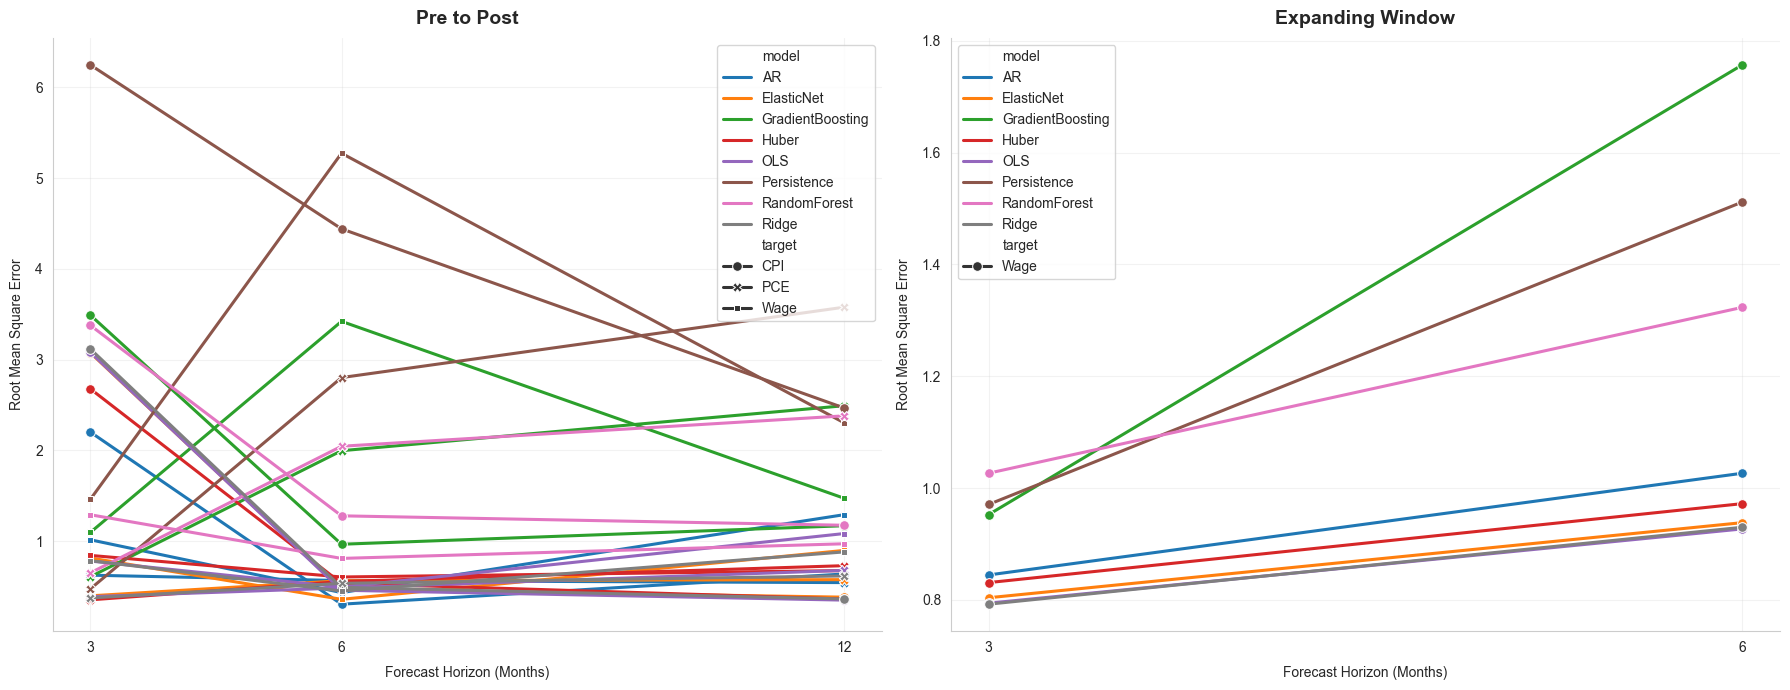

In [35]:
forecast_plot_data = score_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, split_name in zip(axes, ["Pre to Post", "Expanding Window"]):
    split_data = forecast_plot_data.loc[forecast_plot_data["split"].eq(split_name)].copy()

    if split_data.empty:
        ax.set_axis_off()
        continue

    split_data = split_data.sort_values(["target", "model", "horizon"])

    sns.lineplot(
        data=split_data,
        x="horizon",
        y="rmse",
        hue="model",
        style="target",
        markers=True,
        dashes=False,
        linewidth=2.2,
        markersize=7,
        ax=ax,
    )

    ax.set_title(split_name, pad=10, fontsize=14, weight="bold")
    ax.set_xlabel("Forecast Horizon (Months)", labelpad=8)
    ax.set_ylabel("Root Mean Square Error", labelpad=8)
    ax.set_xticks(sorted(split_data["horizon"].unique()))
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(fig_root / "05_forecast_benchmark_errors.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

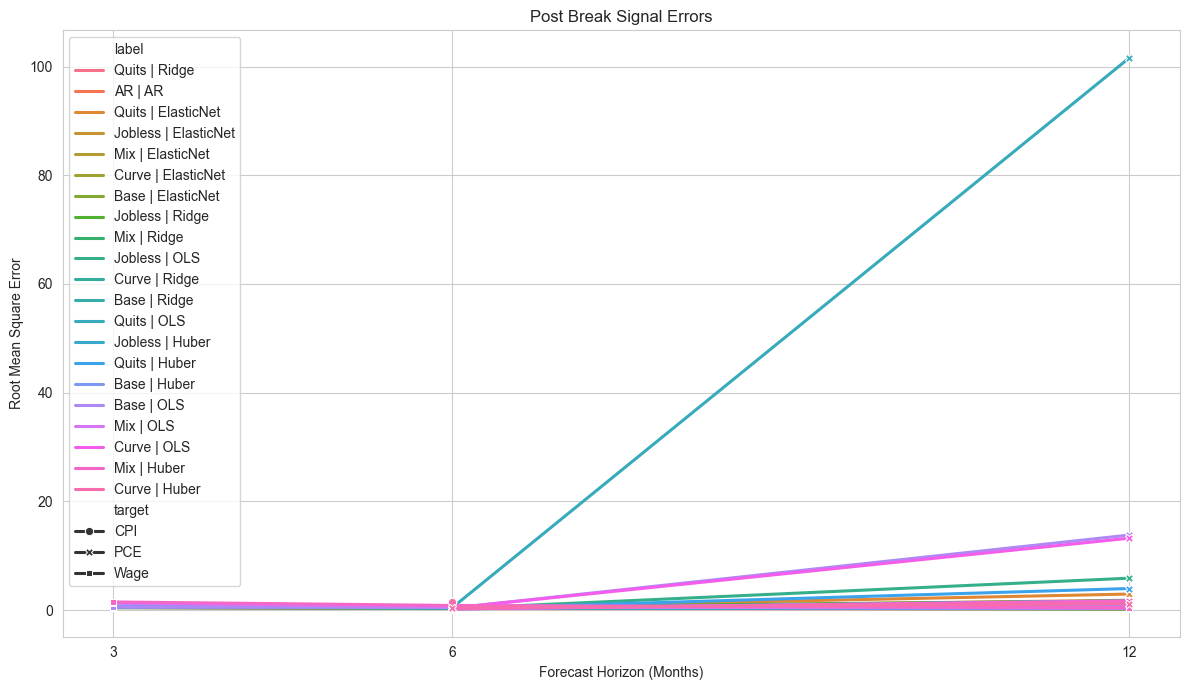

In [36]:
plot_post = post_table.copy()

fig, ax = plt.subplots(figsize=(12, 7))

if not plot_post.empty:
    plot_post["label"] = plot_post["mode"] + " | " + plot_post["model"]

    sns.lineplot(
        data=plot_post,
        x="horizon",
        y="rmse",
        hue="label",
        style="target",
        markers=True,
        dashes=False,
        linewidth=2.2,
        ax=ax,
    )

ax.set_title("Post Break Signal Errors")
ax.set_xlabel("Forecast Horizon (Months)")
ax.set_ylabel("Root Mean Square Error")

if not plot_post.empty:
    ax.set_xticks(sorted(plot_post["horizon"].dropna().unique()))

ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(fig_root / "05_forecast_benchmark_post_signal_errors.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

In [37]:
score_summary.to_csv(report_root / "05_forecast_benchmark_summary.csv", index=False)
best_summary.to_csv(report_root / "05_forecast_benchmark_best_models.csv", index=False)
gain_summary.to_csv(report_root / "05_forecast_benchmark_gain_vs_ar.csv", index=False)

split_scores.to_csv(report_root / "05_forecast_benchmark_pre_post_scores.csv", index=False)
window_scores.to_csv(report_root / "05_forecast_benchmark_window_scores.csv", index=False)
post_table.to_csv(report_root / "05_forecast_benchmark_post_scores.csv", index=False)

signal_best.to_csv(report_root / "05_forecast_benchmark_signal_best.csv", index=False)
signal_win.to_csv(report_root / "05_forecast_benchmark_signal_wins.csv", index=False)
clark_data.to_csv(report_root / "05_forecast_benchmark_clark_west.csv", index=False)

split_predictions.to_csv(model_root / "05_forecast_benchmark_pre_post_predictions.csv", index=False)
window_predictions.to_csv(model_root / "05_forecast_benchmark_window_predictions.csv", index=False)
post_preds.to_csv(model_root / "05_forecast_benchmark_post_predictions.csv", index=False)

In [38]:
display(best_summary.round(show_dec))
display(gain_summary.round(show_dec))
display(signal_best.round(show_dec))
display(signal_win.round(show_dec))
display(clark_data.round(show_dec))

,split,target_col,target,horizon,model,rmse,mae,oos_r2,row_count,rmse_rank,mae_rank,avg_rank
0,Expanding Window,wage_target_3,Wage,3,Ridge,0.7923,0.6260,0.3833,54,1.0000,1.0000,1.0000
1,Expanding Window,wage_target_6,Wage,6,OLS,0.9270,0.6992,0.7031,45,1.0000,2.0000,1.5000
2,Pre to Post,cpi_target_3,CPI,3,AR,2.2018,1.8190,0.8758,4,1.0000,1.0000,1.0000
3,Pre to Post,cpi_target_6,CPI,6,AR,0.3039,0.2510,0.9953,12,1.0000,1.0000,1.0000
4,Pre to Post,cpi_target_12,CPI,12,OLS,0.3489,0.2765,0.9800,5,1.0000,1.0000,1.0000
5,Pre to Post,pce_target_3,PCE,3,Huber,0.3518,0.2995,0.4441,2,1.0000,1.0000,1.0000
6,Pre to Post,pce_target_6,PCE,6,Ridge,0.5339,0.3531,0.9637,11,2.0000,1.0000,1.5000
7,Pre to Post,pce_target_12,PCE,12,AR,0.5420,0.4355,0.9770,7,1.0000,1.0000,1.0000
8,Pre to Post,wage_target_3,Wage,3,OLS,0.7796,0.6357,0.7144,16,1.0000,1.0000,1.0000
9,Pre to Post,wage_target_6,Wage,6,ElasticNet,0.3576,0.2828,0.9954,18,1.0000,1.0000,1.0000


,split,target_col,target,horizon,model,rmse,mae,oos_r2,row_count,ar_rmse,ar_mae,ar_oos_r2,rmse_gain_vs_ar,mae_gain_vs_ar
0,Expanding Window,wage_target_3,Wage,3,Ridge,0.7923,0.6260,0.3833,54,0.8446,0.6783,0.2600,0.0523,0.0523
1,Expanding Window,wage_target_6,Wage,6,OLS,0.9270,0.6992,0.7031,45,1.0266,0.6894,0.5526,0.0996,-0.0099
2,Pre to Post,cpi_target_3,CPI,3,AR,2.2018,1.8190,0.8758,4,2.2018,1.8190,0.8758,0.0000,0.0000
3,Pre to Post,cpi_target_6,CPI,6,AR,0.3039,0.2510,0.9953,12,0.3039,0.2510,0.9953,0.0000,0.0000
4,Pre to Post,cpi_target_12,CPI,12,OLS,0.3489,0.2765,0.9800,5,0.6370,0.5573,0.9334,0.2881,0.2808
5,Pre to Post,pce_target_3,PCE,3,Huber,0.3518,0.2995,0.4441,2,0.6239,0.4467,-0.7483,0.2721,0.1472
6,Pre to Post,pce_target_6,PCE,6,OLS,0.4829,0.3600,0.9703,11,0.5643,0.3663,0.9594,0.0814,0.0063
7,Pre to Post,pce_target_12,PCE,12,AR,0.5420,0.4355,0.9770,7,0.5420,0.4355,0.9770,0.0000,0.0000
8,Pre to Post,wage_target_3,Wage,3,OLS,0.7796,0.6357,0.7144,16,1.0141,0.9063,0.5168,0.2345,0.2705
9,Pre to Post,wage_target_6,Wage,6,ElasticNet,0.3576,0.2828,0.9954,18,0.4318,0.3144,0.9933,0.0743,0.0317


,target_col,model,target,horizon,mode,split,rmse,mae,oos_r2,row_count
0,cpi_target_6,AR,CPI,6,AR,Post Window,0.2599,0.2375,-0.0954,4
1,cpi_target_6,ElasticNet,CPI,6,Quits,Post Window,0.2798,0.2502,-0.0706,4
2,cpi_target_6,Huber,CPI,6,Jobless,Post Window,0.5473,0.4606,-2.2068,4
3,cpi_target_6,OLS,CPI,6,Jobless,Post Window,0.3782,0.2751,-0.9576,4
4,cpi_target_6,Ridge,CPI,6,Quits,Post Window,0.2478,0.2060,0.1160,4
5,pce_target_6,AR,PCE,6,AR,Post Window,0.3095,0.2435,0.3123,2
6,pce_target_6,ElasticNet,PCE,6,Jobless,Post Window,0.3048,0.2375,0.3328,2
7,pce_target_6,Huber,PCE,6,Mix,Post Window,0.2057,0.1469,0.6961,2
8,pce_target_6,OLS,PCE,6,Mix,Post Window,0.2108,0.1918,0.6810,2
9,pce_target_6,Ridge,PCE,6,Mix,Post Window,0.4267,0.3087,-0.3077,2


,mode,win_count,mean_rmse,mean_mae,mean_oos_r2
0,Quits,6,0.3177,0.2716,-0.0467
1,Jobless,6,0.4147,0.3546,-1.4336
2,Mix,6,0.5203,0.4680,-1.0636
3,AR,6,0.5538,0.5164,-1.4425
4,Base,3,0.4691,0.4078,-0.7386
5,Curve,3,1.0651,0.9184,-2.1583


,target,target_col,horizon,model,mode,clark_west,p_value,rows
0,Wage,wage_target_3,3,OLS,Quits,NaN,NaN,6
1,Wage,wage_target_3,3,OLS,Jobless,NaN,NaN,6
2,Wage,wage_target_3,3,OLS,Mix,NaN,NaN,6
3,Wage,wage_target_3,3,OLS,Curve,NaN,NaN,0
4,Wage,wage_target_3,3,Ridge,Quits,NaN,NaN,6
5,Wage,wage_target_3,3,Ridge,Jobless,NaN,NaN,6
6,Wage,wage_target_3,3,Ridge,Mix,NaN,NaN,6
7,Wage,wage_target_3,3,Ridge,Curve,NaN,NaN,0
8,Wage,wage_target_3,3,ElasticNet,Quits,NaN,NaN,6
9,Wage,wage_target_3,3,ElasticNet,Jobless,NaN,NaN,6
